# Tissue Classification — Walkthrough


In [1]:
import os
import glob
from collections import Counter

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
import seaborn as sns
import tifffile
import torch
from PIL import Image

sns.set_theme(style="whitegrid")


# §2 — Preprocessing

With the data understood and the splits decided, we now lock down the preprocessing
pipeline: how we get from a raw 2048×1536 RGB image into the tensor the model sees,
and what augmentations we apply along the way. 



## Step 9 — From loading to preprocessing

We know what the images are, we've fixed the bit-depth mismatch, and we've chosen a split
strategy. The next question is: **once we load an image, how do we feed it to a neural network?**

Let's try these two options:

1. **Crop** a fixed-size patch (say 512×512) from the image at native resolution.
2. **Resize** the whole image to a small (say 224×224) input — the ImageNet-trained-pipeline
   default.
   
For natural images these choices are often close to equivalent. For pathology classes are distinguished by *cellular* morphology (nuclei shape, gland boundaries, mitoses)
that lives at the pixel scale. Let's visualize what each choice actually feeds the model.


**Lets see two side-by-side pipelines on the same image:**

 - A) full-image resize to 224×224  — ImageNet default
 - B) 512×512 center crop at native resolution  — our choice


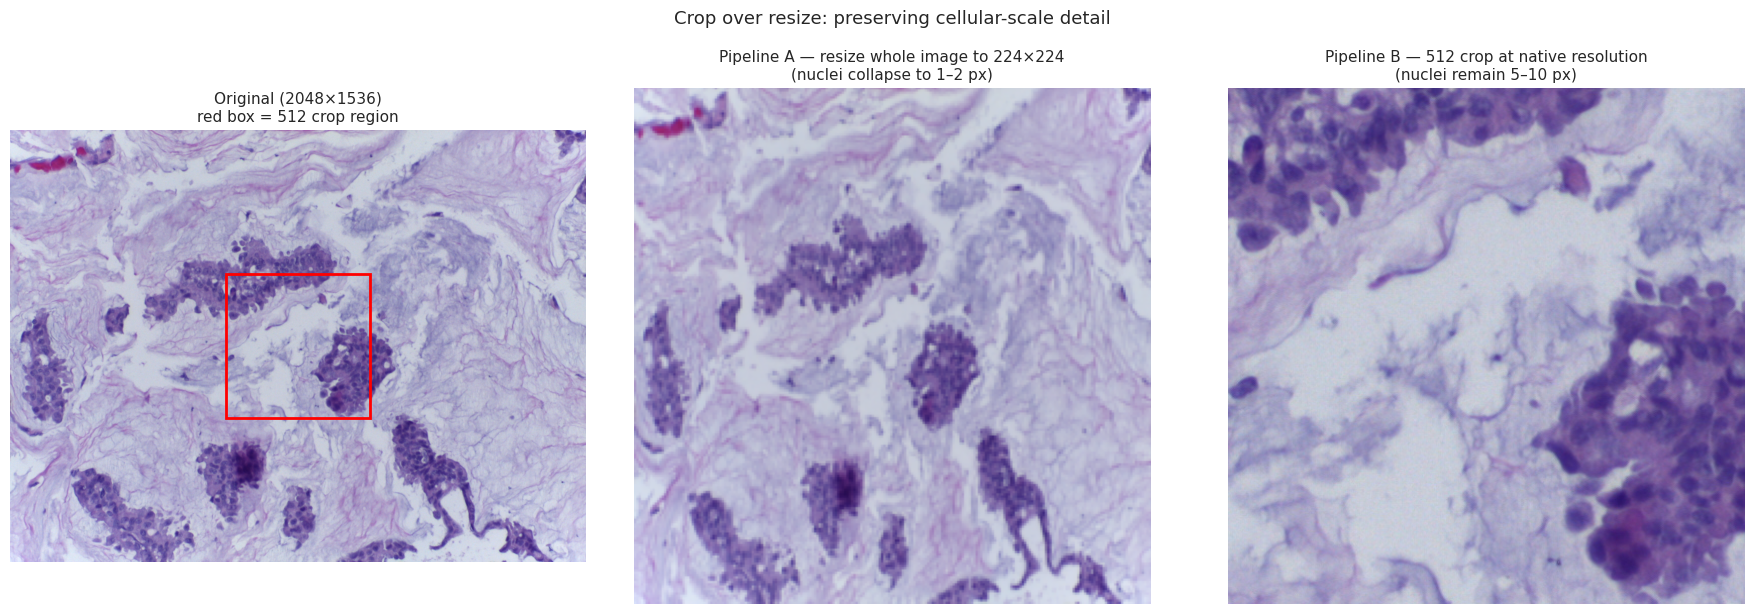

In [14]:
from matplotlib.patches import Rectangle

sample_path = df[df["class"] == "class1"]["path"].iloc[0]
img = load_image(sample_path)
h, w = img.shape[:2]

full_resized = np.array(Image.fromarray(img).resize((224, 224), Image.BILINEAR))

y0, x0 = (h - 512) // 2, (w - 512) // 2
crop_512 = img[y0:y0 + 512, x0:x0 + 512]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(img)
axes[0].add_patch(Rectangle((x0, y0), 512, 512, linewidth=2, edgecolor="red", facecolor="none"))
axes[0].set_title(f"Original ({w}×{h})\nred box = 512 crop region", fontsize=11)
axes[0].axis("off")

axes[1].imshow(full_resized)
axes[1].set_title("Pipeline A — resize whole image to 224×224\n(nuclei collapse to 1–2 px)", fontsize=11)
axes[1].axis("off")

axes[2].imshow(crop_512)
axes[2].set_title("Pipeline B — 512 crop at native resolution\n(nuclei remain 5–10 px)", fontsize=11)
axes[2].axis("off")

plt.suptitle("Crop over resize: preserving cellular-scale detail", y=1.02, fontsize=13)
plt.tight_layout()
plt.show()


### What this figure shows

- **Pipeline A** squashes a 2048×1536 image into 224×224. Nuclei that were 5–10 pixels wide at
  native resolution become 1–2 pixels wide. The information a pathologist uses to tell these
  classes apart is literally averaged away before it reaches the network.
- **Pipeline B** takes a 512×512 *native-resolution* crop. Cellular morphology is preserved.
  The network sees what a microscope user would see at that field of view.

### The obvious cost and how we handle it

A 512 crop only covers part of the image. We address this in two places:

- **Training:** random crops every epoch act as a form of augmentation. The network sees many
  different patches of the same image over training and learns that each class can be identified
  from representative tissue regions, not just from one fixed view.
- **Evaluation:** we aggregate predictions across a non-overlapping 512 grid of the full image and take the **mean of softmax probabilities** to produce
  an image-level label. This keeps training and evaluation consistent, we always score at the
  image level.

### Why this lives in `tissue.py`
We're lifting the shared logic (loader, dataset, transforms, model factory, train/eval helpers) into a single
`tissue.py` module and importing from it in both places. 


## Step 10 — Augmentations: what we use, and why each one is justified

The data is small (n = 400) and the per-class signal is cellular
morphology, so augmentations need to preserve that signal while creating variation the model
generalises over. Concretely we pick:

- **`RandomCrop(512)`** — Every epoch the model sees a different 512-px patch of the same image, so the effective dataset is much larger than 400 samples.
- **`RandomHorizontalFlip` + `RandomVerticalFlip`** — tissue sections have no preferred axis.
  A flipped image of class *k* is still an image of class *k*.
- **Discrete 90° rotations** — we use a custom `DiscreteRotation90` that picks uniformly from
  `{0°, 90°, 180°, 270°}`. We deliberately **do not** use `transforms.RandomRotation(90)`:
  that samples a *continuous* angle in `[-90, 90]`, which introduces bilinear interpolation
  and, more importantly, black border padding. That padding is a strong class-agnostic shortcut
  the network will memorise. Discrete right-angle rotations are exact, no interpolation,
  no padding, no artefacts.
- **ImageNet `Normalize`** — the backbone is ImageNet-pretrained, so we feed it inputs in the
  distribution its weights expect.

**Deliberately deferred to the §4 ablation (not applied in the main pipeline):**

- **HED / stain-aware colour jitter.** H&E stain intensity varies across scanners and labs, so
  perturbing the H/E/D channels is the principled colour-augmentation for pathology. It almost
  certainly helps but "probably helps" isn't a measurement. The ablation table is where we
  quantify whether it's worth including in the final model.



#### Let's wire up the preprocessing pipeline via `tissue.py`. The one source of truth for loading, transforms, and the Dataset class.

In [15]:
from tissue import (
    TissueDataset,
    build_train_transforms,
    build_eval_transforms,
    encode_labels,
    CLASSES,
    IMAGENET_MEAN,
    IMAGENET_STD,
)

paths = df["path"].tolist()
labels = encode_labels(df["class"].tolist())

train_tf = build_train_transforms(crop_size=512)
eval_tf  = build_eval_transforms(crop_size=512)

train_ds = TissueDataset(paths, labels, transform=train_tf)
eval_ds  = TissueDataset(paths, labels, transform=eval_tf)

x, y = train_ds[0]

print(f"Dataset size       : {len(train_ds)}")
print(f"Train tensor shape : {tuple(x.shape)}   dtype: {x.dtype}")
print(f"Label 0 → class    : {CLASSES[y]}")
print(f"Classes (index map): {list(enumerate(CLASSES))}")


Dataset size       : 400
Train tensor shape : (3, 512, 512)   dtype: torch.float32
Label 0 → class    : class1
Classes (index map): [(0, 'class1'), (1, 'class2'), (2, 'class3'), (3, 'class4')]


### Sanity check : what the model actually sees

Before we start training, look at a single batch of augmented samples. If something is broken
(wrong channel order, wrong normalisation stats, crops landing on white background, augmentation
destroying labels), it should be obvious from one figure.


**Let's pull one batch through the training pipeline, de-normalise for display, and render it.**


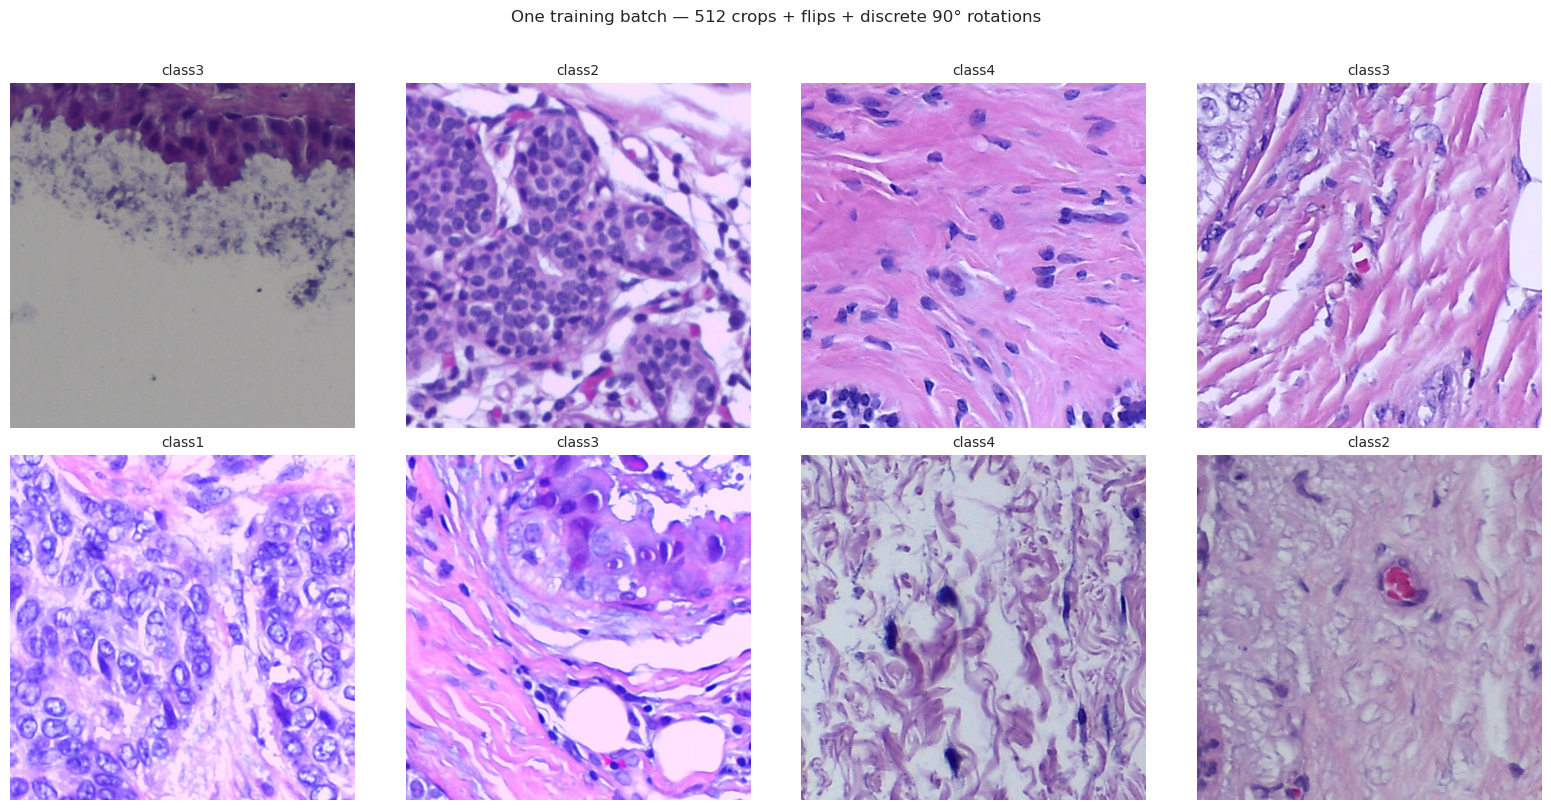

In [16]:
import torch

from torch.utils.data import DataLoader

loader = DataLoader(train_ds, batch_size=8, shuffle=True, num_workers=0)
batch_imgs, batch_labels = next(iter(loader))

mean_t = torch.tensor(IMAGENET_MEAN).view(1, 3, 1, 1)
std_t  = torch.tensor(IMAGENET_STD).view(1, 3, 1, 1)
batch_display = (batch_imgs * std_t + mean_t).clamp(0, 1)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for ax, img, lbl in zip(axes.flat, batch_display, batch_labels):
    ax.imshow(img.permute(1, 2, 0).numpy())
    ax.set_title(CLASSES[lbl.item()], fontsize=10)
    ax.axis("off")

plt.suptitle("One training batch — 512 crops + flips + discrete 90° rotations", fontsize=12, y=1.01)
plt.tight_layout()
plt.show()


### Reading the figure

Each tile is a 512×512 native-resolution crop, post-flip, post-rotation, post-normalisation
(then de-normalised here for display). Two things to look for:

1. **Tissue fills the frame.** If a class's crops regularly land on featureless background,
   `RandomCrop` is picking up more slide-edge than tissue and we'd want a minimum-foreground
   filter or smaller crops. The histology dataset here appears tissue-heavy, so this is fine.
2. **No obvious padding / border artefacts.** Confirms the discrete-rotation choice is doing
   what it should — rotated tiles look identical in quality to un-rotated ones.

We're now ready to train.
